# 5. Scoring Strategy Analysis: OOD Score Distribution

**Table 4 Figure** – 1×4 subfigure layout comparing ID/OOD separation across scoring strategies:

- **Main Only**: Main logits only
- **Uniform Sum**: Main + Aux (each weight 1)
- **Uniform Average**: Main + (1/3)×(Aux_RGB + Aux_Gyro + Aux_Acce)
- **Ours (MoAS)**: Main + α_m × Aux (energy-based adaptive weights)

**Task 0에서 4개 전략 분포가 유사한 이유**: Task 0은 ID 클래스가 적어(8개) auxiliary 기여가 작고, confidence 포화(α≈1/3) 시 Ours ≈ Uniform Average. Task 2/3에서 전략별 차이가 뚜렷해짐.

**Auxiliary logits가 비어 있던 이유**: `auxiliary_head_fusion_v2_7` 사용 시 fusion이 `auxiliary_logits`/`confidences`를 반환. `baseline_tbn`은 `'auxiliary_loss' in fused`일 때만 out에 넣음. concat 등 다른 fusion 사용 시 4개 전략이 모두 main만 사용해 동일했을 수 있음.

Reference: `scripts-eval/TBN/All/All_v2_7/5.uestc-mmea-mmeader-herding.yaml`

In [1]:
# ========== 셀 1: 프로젝트 경로 설정 ==========
# notebook 폴더에서 실행 시 상위 디렉토리를 프로젝트 루트로 설정
import os
import sys

cwd = os.getcwd()
if os.path.basename(cwd) == 'notebook':
    PROJECT_ROOT = os.path.abspath(os.path.join(cwd, '..'))
else:
    PROJECT_ROOT = cwd

os.chdir(PROJECT_ROOT)
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print(f'Working directory: {os.getcwd()}')

Working directory: /workspace/MMEA-MoAS


In [2]:
# ========== 셀 2: 라이브러리 임포트 ==========
# OOD 평가에 필요한 라이브러리: numpy, torch, sklearn(roc_auc, roc_curve), matplotlib, scipy(gaussian_kde)
import ast
import copy
import json
from glob import glob

import numpy as np
import pandas as pd
import torch
# import torch.nn.functional as F  # 미사용
from torch.utils.data import DataLoader
from tqdm import tqdm
from scipy.stats import gaussian_kde
from sklearn.metrics import roc_auc_score, roc_curve  # average_precision_score 미사용

import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams['figure.dpi'] = 120
matplotlib.rcParams['figure.facecolor'] = 'white'
matplotlib.rcParams['axes.spines.top'] = False
matplotlib.rcParams['axes.spines.right'] = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


## 1. Configuration

In [3]:
# ========== 셀 3: 실험 설정 및 유틸 함수 ==========
# METHOD: 모델 이름 (tbn_mmeader)
# INCREMENT: 클래스 증분 수 (inc4 → 4개씩 추가)
# TARGET_TASK_ID: 평가할 task (해당 task의 checkpoint 로드)
# FORCE_CHECKPOINT_DIR: 지정 시 자동 탐색 대신 이 경로의 가중치 사용
METHOD = 'tbn_mmeader'
INCREMENT = 4
TARGET_TASK_ID = 6   # task_6_checkpoint_6.pkl
SEED = 1993
# 지정 시 자동 탐색 대신 이 경로 사용 (None이면 find_candidate_checkpoint_dirs 결과 사용)
FORCE_CHECKPOINT_DIR = 'logs/mmea_tbn_mmeader_auxiliary_head_v2_7_rgbgyroacce_ep50_bs8_pb1_fr0_inc4_mem320/herding/seed_1993/weights/alpha0.3_temp6_aux0.5'
MODALITIES = ['RGB', 'Gyro', 'Acce']
EXEMPLAR_SELECTION = 'herding'
PREFERRED_WEIGHTS_TAG = 'alpha0.3_temp6_aux0.5'

BASE_CONFIG_PATH = 'exps/exp_mmea_tbn_mmeader.json'

FIGURE_DIR = os.path.join('notebook', 'figures', 'scoring_strategy')
RESULT_DIR = os.path.join('notebook', 'results', 'scoring_strategy')
os.makedirs(FIGURE_DIR, exist_ok=True)
os.makedirs(RESULT_DIR, exist_ok=True)

# save_figure: 그림을 FIGURE_DIR에 저장
def save_figure(filename, **kwargs):
    out_path = os.path.join(FIGURE_DIR, filename)
    plt.savefig(out_path, **kwargs)
    print(f'Saved: {out_path}')

# _count_checkpoints: checkpoint 디렉토리 내 task_*_checkpoint_*.pkl 파일 개수
def _count_checkpoints(checkpoint_dir):
    files = glob(os.path.join(checkpoint_dir, 'task_*_checkpoint_*.pkl'))
    return len(files)

# _has_task0_checkpoint: task_0_checkpoint_0.pkl 존재 여부 (유효한 학습 결과인지 확인)
def _has_task0_checkpoint(checkpoint_dir):
    return os.path.isfile(os.path.join(checkpoint_dir, 'task_0_checkpoint_0.pkl'))

# find_candidate_checkpoint_dirs: increment, seed에 맞는 checkpoint 디렉토리 목록 탐색
def find_candidate_checkpoint_dirs(increment, seed):
    pattern = f'logs/mmea_{METHOD}*inc{increment}*/**/seed_{seed}/weights'
    weight_roots = [p for p in glob(pattern, recursive=True) if os.path.isdir(p)]
    candidates = set()
    for root in weight_roots:
        if _has_task0_checkpoint(root):
            candidates.add(os.path.abspath(root))
        for child in glob(os.path.join(root, '*')):
            if os.path.isdir(child) and _has_task0_checkpoint(child):
                candidates.add(os.path.abspath(child))
    return sorted(candidates)

# choose_checkpoint_dir: 후보 중 preferred_tag 포함, exemplar_selection 일치, checkpoint 수 많은 순으로 선택
def choose_checkpoint_dir(candidates, preferred_tag=PREFERRED_WEIGHTS_TAG, exemplar_selection=EXEMPLAR_SELECTION):
    if not candidates:
        return None
    def score(path):
        return (
            int(preferred_tag in path),
            int(f'/{exemplar_selection}/' in path),
            _count_checkpoints(path),
            os.path.getmtime(path),
        )
    return max(candidates, key=score)

# resolve_seed_dir_from_checkpoint_dir: checkpoint 경로에서 seed_* 디렉토리 경로 추출
def resolve_seed_dir_from_checkpoint_dir(checkpoint_dir):
    cur = os.path.abspath(checkpoint_dir)
    while True:
        base = os.path.basename(cur)
        if base.startswith('seed_'):
            return cur
        parent = os.path.dirname(cur)
        if parent == cur:
            break
        cur = parent
    return None

# load_run_args: seed 디렉토리의 args.txt에서 학습 시 사용한 설정 로드
def load_run_args(seed_dir):
    if seed_dir is None:
        return {}
    args_path = os.path.join(seed_dir, 'args.txt')
    if not os.path.isfile(args_path):
        return {}
    try:
        with open(args_path, 'r') as f:
            return ast.literal_eval(f.read().strip())
    except Exception:
        return {}

# build_eval_config: 평가용 config 생성. run_args로 fusion_type, confidence_method 등 학습 설정 반영
def build_eval_config(increment, seed, run_args=None):
    run_args = run_args or {}
    with open(BASE_CONFIG_PATH, 'r') as f:
        cfg = json.load(f)
    for key in ['fusion_type', 'consensus_type', 'before_softmax', 'num_segments', 'dropout',
                'pretrain_epochs', 'confidence_method', 'aux_loss_weight', 'exemplar_selection',
                'mmeader_alpha', 'mmeader_temp', 'train_list', 'test_list', 'mpu_path', 'dataset',
                'arch', 'backbone', 'memory_size', 'partialbn', 'freeze']:
        if key in run_args:
            cfg[key] = run_args[key]
    cfg['mode'] = 'eval'
    cfg['model_name'] = METHOD
    cfg['seed'] = seed
    cfg['increment'] = increment
    cfg['init_cls'] = increment
    cfg['modality'] = MODALITIES
    cfg['workers'] = 0
    cfg['batch_size'] = 8
    cfg['use_wandb'] = False
    cfg['enable_ood'] = False
    cfg['shuffle'] = False
    cfg['device'] = [0]
    return cfg

print('Configuration ready.')
print(f'  Method: {METHOD}, Increment: {INCREMENT}, Seed: {SEED}')
print(f'  Figure dir: {FIGURE_DIR}')

Configuration ready.
  Method: tbn_mmeader, Increment: 4, Seed: 1993
  Figure dir: notebook/figures/scoring_strategy


## 2. Model and Data Utilities

In [4]:
# ========== 셀 4: 모델 및 데이터 유틸리티 ==========
import dataloader.data_manager as dm
from utils.utils import set_random_seed, set_device
from models.model_factory import get_model
from dataloader.data_manager import TBNDataManager

# TBNDummyDataset.get 패치: 데이터 로드 실패 시 더미 데이터 반환 (노트북 안정성)
if not hasattr(dm.TBNDummyDataset, '_original_get'):
    dm.TBNDummyDataset._original_get = dm.TBNDummyDataset.get

def _safe_get(self, modality, record, indices):
    try:
        return dm.TBNDummyDataset._original_get(self, modality, record, indices)
    except TypeError:
        if modality in ['RGB', 'RGBDiff', 'Flow']:
            from PIL import Image
            dummy_img = Image.new('RGB', (224, 224), (0, 0, 0))
            n_frames = len(indices) * self.new_length[modality]
            images = [dummy_img] * n_frames
            return self.transform[modality](images)
        if modality in ['Gyro', 'Acce']:
            return torch.zeros(self.num_segments, 3, 24, 1)
        raise

dm.TBNDummyDataset.get = _safe_get

# safe_collate: None 또는 불완전한 샘플 제거 후 배치 구성
def safe_collate(batch):
    valid = [item for item in batch if item is not None]
    try:
        for item in valid:
            idx, inp, label = item
            if isinstance(inp, dict) and any(v is None for v in inp.values()):
                valid = [x for x in valid if x != item]
    except Exception:
        pass
    if len(valid) == 0:
        return None
    return torch.utils.data.dataloader.default_collate(valid)

# create_model_and_data_manager: config로 모델 생성 및 TBNDataManager 초기화
def create_model_and_data_manager(config):
    cfg = copy.deepcopy(config)
    set_random_seed(cfg['seed'])
    cfg['device'] = set_device(cfg['device'])
    model = get_model(cfg['model_name'], cfg)
    image_tmpl = {m: '{:06d}.jpg' for m in cfg['modality'] if m in ['RGB', 'RGBDiff']}
    if 'Flow' in cfg['modality']:
        image_tmpl['Flow'] = '{}_{:06d}.jpg'
    data_manager = TBNDataManager(model, image_tmpl, cfg)
    return model, data_manager, cfg

# setup_task_model: task_id에 맞게 FC 업데이트, fusion.update_task 호출, checkpoint 로드, ID/OOD DataLoader 생성
def setup_task_model(model, data_manager, task_id, checkpoint_dir, device):
    # total_classes: task 0~task_id까지 누적 클래스 수 (예: inc4 task2 → 4+4+4=12)
    total_classes = sum(data_manager.get_task_size(t) for t in range(task_id + 1))
    model._cur_task = task_id
    model._total_classes = total_classes
    model._classes_seen_so_far = total_classes
    model._known_classes = total_classes - data_manager.get_task_size(task_id)
    model._network.update_fc(total_classes)

    # Fusion module에 task_id 전달 (auxiliary head 상태 동기화)
    if hasattr(model._network, 'fusion') and hasattr(model._network.fusion, 'update_task'):
        model._network.fusion.update_task(task_id)

    ckpt_path = os.path.join(checkpoint_dir, f'task_{task_id}_checkpoint_{task_id}.pkl')
    if not os.path.isfile(ckpt_path):
        raise FileNotFoundError(f'Checkpoint not found: {ckpt_path}')

    ckpt = torch.load(ckpt_path, map_location='cpu', weights_only=False)
    model._network.load_state_dict(ckpt['model_state_dict'], strict=False)
    model._network.to(device)
    model._network.eval()

    # ID: 클래스 0~(total_classes-1). OOD: total_classes~전체클래스 (아직 학습 안 한 클래스)
    id_dataset = data_manager.get_dataset(np.arange(0, total_classes), source='test', mode='test')
    id_loader = DataLoader(id_dataset, batch_size=8, shuffle=False, num_workers=0, collate_fn=safe_collate)

    ood_loader = None
    total_classnum = data_manager.get_total_classnum()
    if total_classes < total_classnum:
        ood_dataset = data_manager.get_dataset(np.arange(total_classes, total_classnum), source='test', mode='test')
        ood_loader = DataLoader(ood_dataset, batch_size=8, shuffle=False, num_workers=0, collate_fn=safe_collate)

    return id_loader, ood_loader, total_classes, total_classnum

# list_available_task_ids: checkpoint 디렉토리 내 task_*_checkpoint_*.pkl에서 task ID 목록 추출
def list_available_task_ids(checkpoint_dir):
    ckpts = glob(os.path.join(checkpoint_dir, 'task_*_checkpoint_*.pkl'))
    task_ids = []
    for p in ckpts:
        try:
            tid = int(os.path.basename(p).split('_')[1])
            task_ids.append(tid)
        except Exception:
            pass
    return sorted(set(task_ids))

print('Model/data utilities ready.')

Model/data utilities ready.


## 3. Score Extraction and Fusion Logic

In [5]:
def to_device_inputs(inputs, device):
    if isinstance(inputs, dict):
        return {k: v.to(device) for k, v in inputs.items()}
    return inputs.to(device)

# extract_outputs: DataLoader로 batch 추론 → main_logits, aux_logits(RGB/Gyro/Acce), confidences 수집
def extract_outputs(model, loader, device, modalities):
    model._network.eval()
    all_main_logits, all_labels = [], []  # all_labels: 미사용 (주석 처리됨)
    all_aux_logits = {m: [] for m in modalities}
    all_confidences = {m: [] for m in modalities}

    with torch.no_grad():
        for batch in tqdm(loader, leave=False):
            if batch is None:
                continue
            try:
                _, inputs, targets = batch
                inputs = to_device_inputs(inputs, device)
                outputs = model._network(inputs)
                main_logits = outputs.get('logits', None)
                aux_logits = outputs.get('auxiliary_logits') or {}
                confidences = outputs.get('confidences') or {}
                if main_logits is None:
                    continue
                all_main_logits.append(main_logits.detach().cpu())
                # all_labels.append(targets.detach().cpu())  # 미사용
                for m in modalities:
                    all_aux_logits[m].append(aux_logits.get(m, torch.zeros_like(main_logits)).detach().cpu())
                    all_confidences[m].append(confidences.get(m, torch.zeros(main_logits.size(0))).detach().cpu())
            except Exception:
                continue

    if len(all_main_logits) == 0:
        return None
    return {
        'main_logits': torch.cat(all_main_logits, dim=0).numpy(),
        # 'labels': torch.cat(all_labels, dim=0).numpy(),  # 미사용
        'aux_logits': {m: torch.cat(all_aux_logits[m], dim=0).numpy() for m in modalities},
        'confidences': {m: torch.cat(all_confidences[m], dim=0).numpy() for m in modalities},
    }

def compute_scores_via_detector(model, id_out, ood_out, device, modalities, method_name):
    """UnifiedOODDetector로 OOD 점수 계산 (Main Only, Uniform Sum, Ours)"""
    from ood import UnifiedOODDetector
    def scores_from_out(out):
        # 호출마다 새 detector 생성 (ConfNormalized의 _alpha_logged 버그 우회)
        detector = UnifiedOODDetector.from_method_name(model._network, method_name, device=device)
        outputs = {
            'logits': torch.from_numpy(out['main_logits']).float().to(device),
            'auxiliary_logits': {m: torch.from_numpy(out['aux_logits'][m]).float().to(device) for m in modalities},
            'confidences': {m: torch.from_numpy(out['confidences'][m]).float().to(device) for m in modalities},
        }
        return detector.compute_scores_from_outputs(outputs)
    return scores_from_out(id_out), scores_from_out(ood_out)

# fuse_uniform_sum: Main + Aux_RGB + Aux_Gyro + Aux_Acce (각 가중치 1)
def fuse_uniform_sum(main_np, aux_dict, modalities):
    fused = main_np.copy()
    for m in modalities:
        fused = fused + aux_dict[m]
    return fused

# fuse_uniform_average: Main + (1/3)*(Aux_RGB + Aux_Gyro + Aux_Acce). detector에 해당 모드 없어 수동 구현
def fuse_uniform_average(main_np, aux_dict, modalities):
    """Uniform Average: Main + (1/3)*(Aux_RGB + Aux_Gyro + Aux_Acce). detector에 해당 모드 없음."""
    fused = main_np.copy()
    for m in modalities:
        fused = fused + (1.0 / len(modalities)) * aux_dict[m]
    return fused

# maxlogit_score: logits에서 max(logits, dim=1) → OOD novelty score (높을수록 ID에 가까움)
def maxlogit_score(logits_np):
    return np.max(logits_np, axis=1)

# compute_ood_metrics: ID/OOD 점수로 AUROC, FPR95 계산
def compute_ood_metrics(id_scores, ood_scores):
    y_true = np.concatenate([np.ones(len(id_scores)), np.zeros(len(ood_scores))])
    y_scores = np.concatenate([id_scores, ood_scores])
    try:
        auroc = roc_auc_score(y_true, y_scores) * 100
    except Exception:
        auroc = 50.0
    try:
        fpr, tpr, _ = roc_curve(y_true, y_scores)
        idx = np.searchsorted(tpr, 0.95)
        fpr95 = fpr[min(idx, len(fpr) - 1)] * 100
    except Exception:
        fpr95 = 100.0
    return {'AUROC': auroc, 'FPR95': fpr95}

print('Score and fusion functions ready.')

Score and fusion functions ready.


## 4. Run Evaluation and Collect Scores

In [6]:
# ========== 셀 6: 평가 실행 및 4개 전략 점수 수집 ==========
# FORCE_CHECKPOINT_DIR이 있으면 해당 경로 사용, 없으면 find_candidate_checkpoint_dirs로 자동 탐색
if FORCE_CHECKPOINT_DIR and os.path.isdir(FORCE_CHECKPOINT_DIR):
    checkpoint_dir = os.path.abspath(FORCE_CHECKPOINT_DIR)
    print(f'Using FORCE_CHECKPOINT_DIR: {checkpoint_dir}')
else:
    candidates = find_candidate_checkpoint_dirs(INCREMENT, SEED)
    if len(candidates) == 0 and INCREMENT == 8:
        candidates = find_candidate_checkpoint_dirs(4, SEED)
        if candidates:
            INCREMENT = 4
            TARGET_TASK_ID = 2
            print('inc8 not found. Using inc4, task 2.')
    if len(candidates) == 0:
        raise RuntimeError(f'No checkpoint found for inc{INCREMENT} seed{SEED}. Run training first.')
    checkpoint_dir = choose_checkpoint_dir(candidates)
seed_dir = resolve_seed_dir_from_checkpoint_dir(checkpoint_dir)
run_args = load_run_args(seed_dir)

print(f'Checkpoint dir: {checkpoint_dir}')

config = build_eval_config(INCREMENT, SEED, run_args=run_args)
model, data_manager, config = create_model_and_data_manager(config)

# fusion.set_epoch(pretrain_epochs): 평가 시 auxiliary head frozen 상태로 설정 (confidence 정상 계산)
pretrain_epochs = config.get('pretrain_epochs', 50)
if hasattr(model._network, 'fusion') and hasattr(model._network.fusion, 'set_epoch'):
    model._network.fusion.set_epoch(pretrain_epochs)
    print(f'Fusion set to frozen phase (epoch={pretrain_epochs})')

# available_task_ids: checkpoint에 있는 task 목록. valid_task_ids: OOD가 있는 task만 (마지막 task 제외)
available_task_ids = list_available_task_ids(checkpoint_dir)
valid_task_ids = [t for t in available_task_ids if t < data_manager.nb_tasks - 1]
# eval_task_id: TARGET_TASK_ID가 유효하면 사용, 아니면 마지막 유효 task 사용
eval_task_id = TARGET_TASK_ID if TARGET_TASK_ID in valid_task_ids else valid_task_ids[-1]

print(f'Tasks with OOD: {valid_task_ids}')
print(f'Evaluating Task {eval_task_id}')

all_scores = {
    'Main Only': {'id': None, 'ood': None, 'metrics': None},
    'Uniform Sum': {'id': None, 'ood': None, 'metrics': None},
    'Uniform Average': {'id': None, 'ood': None, 'metrics': None},
    'Ours': {'id': None, 'ood': None, 'metrics': None},
}

for task_id in [eval_task_id]:
    id_loader, ood_loader, n_id, n_total = setup_task_model(model, data_manager, task_id, checkpoint_dir, DEVICE)
    if ood_loader is None:
        continue

    # ID/OOD 데이터로 모델 추론 → main_logits, aux_logits, confidences 추출
    id_out = extract_outputs(model, id_loader, DEVICE, MODALITIES)
    ood_out = extract_outputs(model, ood_loader, DEVICE, MODALITIES)
    if id_out is None or ood_out is None:
        continue

    main_id, main_ood = id_out['main_logits'], ood_out['main_logits']
    aux_id, aux_ood = id_out['aux_logits'], ood_out['aux_logits']

    # 4개 전략별 OOD 점수 계산 (Main/Sum/Ours: UnifiedOODDetector, Avg: 수동 fuse_uniform_average)
    scores_main_id, scores_main_ood = compute_scores_via_detector(model, id_out, ood_out, DEVICE, MODALITIES, 'MaxLogit_Baseline')
    scores_sum_id, scores_sum_ood = compute_scores_via_detector(model, id_out, ood_out, DEVICE, MODALITIES, 'MaxLogit_Hybrid_NoWeight')
    fused_avg_id = fuse_uniform_average(main_id, aux_id, MODALITIES)
    fused_avg_ood = fuse_uniform_average(main_ood, aux_ood, MODALITIES)
    scores_avg_id, scores_avg_ood = maxlogit_score(fused_avg_id), maxlogit_score(fused_avg_ood)
    scores_ours_id, scores_ours_ood = compute_scores_via_detector(model, id_out, ood_out, DEVICE, MODALITIES, 'MaxLogit_Hybrid_ConfNormalized')

    # Verification: Aux L1 mean, Conf mean
    print('\n🔍 Verification (auxiliary logits):')
    for m in MODALITIES:
        aux_l1 = np.abs(aux_id[m]).mean()
        conf_mean = id_out['confidences'][m].mean()
        print(f'  Aux {m} L1 mean: {aux_l1:.4f}  |  Conf mean: {conf_mean:.4f}')
    diff_sum = np.abs(fuse_uniform_sum(main_id, aux_id, MODALITIES) - main_id).mean()
    diff_avg = np.abs(fused_avg_id - main_id).mean()
    print(f'  Strategy divergence from Main Only: Sum={diff_sum:.4f}, Avg={diff_avg:.4f}')
    if diff_sum < 1e-6 and diff_avg < 1e-6:
        print('  ⚠️ WARNING: Main/Sum/Avg identical (auxiliary may be empty/zero)')
    else:
        print('  ✅ 4 strategies differ (auxiliary loaded correctly)')

    m_main = compute_ood_metrics(scores_main_id, scores_main_ood)
    m_sum = compute_ood_metrics(scores_sum_id, scores_sum_ood)
    m_avg = compute_ood_metrics(scores_avg_id, scores_avg_ood)
    m_ours = compute_ood_metrics(scores_ours_id, scores_ours_ood)

    all_scores['Main Only'] = {'id': scores_main_id, 'ood': scores_main_ood, 'metrics': m_main}
    all_scores['Uniform Sum'] = {'id': scores_sum_id, 'ood': scores_sum_ood, 'metrics': m_sum}
    all_scores['Uniform Average'] = {'id': scores_avg_id, 'ood': scores_avg_ood, 'metrics': m_avg}
    all_scores['Ours'] = {'id': scores_ours_id, 'ood': scores_ours_ood, 'metrics': m_ours}

    # [Debug] aux_norms, conf_means 출력 (필요시 주석 해제)
    # aux_norms = {m: np.abs(aux_id[m]).mean() for m in MODALITIES}
    # print(f'  [Debug] Aux L1 mean: {aux_norms}')
    # conf_means = {m: id_out['confidences'][m].mean() for m in MODALITIES}
    # print(f'  [Debug] Conf mean: {conf_means}')

print(f'Task {eval_task_id} results:')
for name, d in all_scores.items():
    if d['metrics']:
        print(f"  {name}: AUROC={d['metrics']['AUROC']:.2f}%, FPR95={d['metrics']['FPR95']:.2f}%")

Using FORCE_CHECKPOINT_DIR: /workspace/MMEA-MoAS/logs/mmea_tbn_mmeader_auxiliary_head_v2_7_rgbgyroacce_ep50_bs8_pb1_fr0_inc4_mem320/herding/seed_1993/weights/alpha0.3_temp6_aux0.5
Checkpoint dir: /workspace/MMEA-MoAS/logs/mmea_tbn_mmeader_auxiliary_head_v2_7_rgbgyroacce_ep50_bs8_pb1_fr0_inc4_mem320/herding/seed_1993/weights/alpha0.3_temp6_aux0.5
Init Gyro model weight
Done. Gyro model ready.
Init Acce model weight
Done. Acce model ready.


🔍 BaselineTBN Debug:
   Modality count: 3
   Backbone feature_dim: 1024
   After fusion feature_dim: 512
🔧 Set fusion.num_segments = 8
✅ Baseline Model Configuration
----------------------------------------
  Backbone:        tbn
  Fusion:          auxiliary_head_v2_7
  Modality:        ['RGB', 'Gyro', 'Acce']
  Segments:        8
  Dropout:         0.5
  Consensus:       avg
video number:5206
video number:1316
Fusion set to frozen phase (epoch=50)
Tasks with OOD: [0, 1, 2, 3, 4, 5, 6]
Evaluating Task 6
🔍 TBNClassification Debug:
   Modality count: 3


🔍 Verification (auxiliary logits):
  Aux RGB L1 mean: 6.8266  |  Conf mean: 0.8391
  Aux Gyro L1 mean: 1.8071  |  Conf mean: 0.8255
  Aux Acce L1 mean: 3.4236  |  Conf mean: 0.9238
  Strategy divergence from Main Only: Sum=9.3780, Avg=3.1260
  ✅ 4 strategies differ (auxiliary loaded correctly)
Task 6 results:
  Main Only: AUROC=89.55%, FPR95=47.85%
  Uniform Sum: AUROC=86.51%, FPR95=61.96%
  Uniform Average: AUROC=90.23%, FPR95=48.47%
  Ours: AUROC=89.90%, FPR95=49.69%


## 5. Visualization: 1×4 Scoring Strategy Figure

Saved: notebook/figures/scoring_strategy/scoring_strategy_ood_distribution_1x4.png


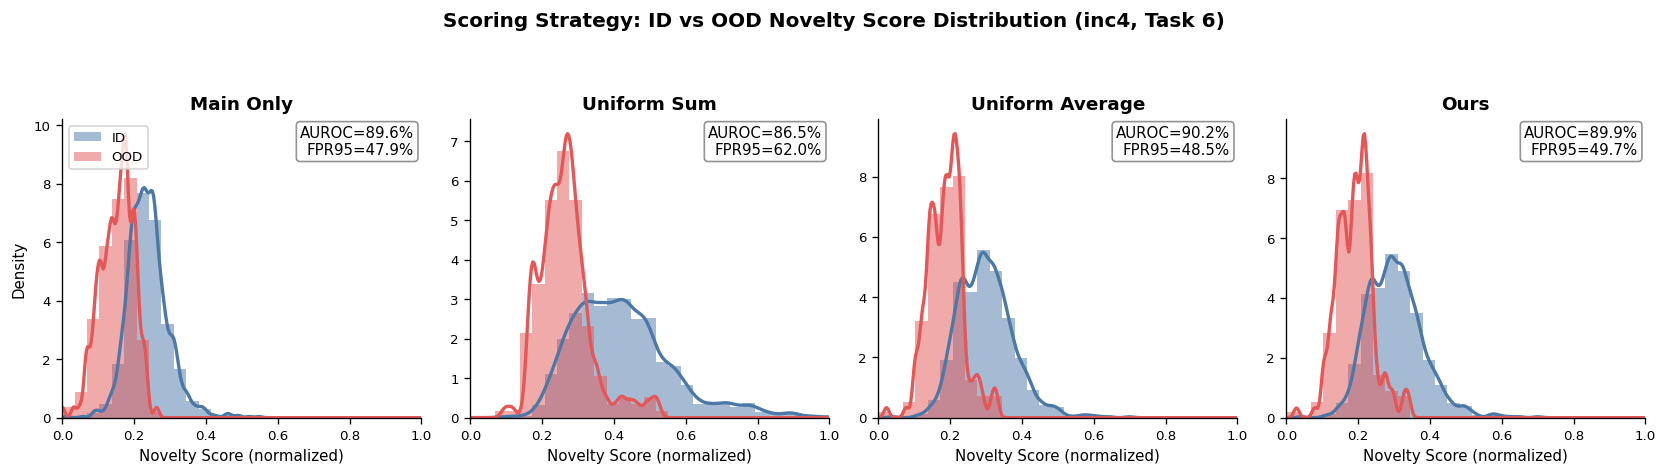

In [7]:
# ========== 셀 7: 1×4 Scoring Strategy 시각화 ==========
ID_COLOR = '#4C78A8'  # ID 분포 색상 (파랑)
OOD_COLOR = '#E45756'  # OOD 분포 색상 (빨강)

# plot_ood_distribution: ID/OOD novelty score 히스토그램 + KDE 곡선, AUROC/FPR95 표시. s_min/s_max로 전역 정규화
def plot_ood_distribution(ax, id_scores, ood_scores, title='', metrics=None, show_xlabel=True, show_ylabel=True, show_legend=False, s_min=None, s_max=None):
    if s_min is None or s_max is None:
        all_local = np.concatenate([id_scores, ood_scores])
        s_min, s_max = all_local.min(), all_local.max()
    s_range = max(s_max - s_min, 1e-8)
    id_norm = (id_scores - s_min) / s_range
    ood_norm = (ood_scores - s_min) / s_range
    bins = np.linspace(0, 1, 30)
    ax.hist(id_norm, bins=bins, density=True, alpha=0.5, color=ID_COLOR, label='ID', histtype='stepfilled')
    ax.hist(ood_norm, bins=bins, density=True, alpha=0.5, color=OOD_COLOR, label='OOD', histtype='stepfilled')
    xs = np.linspace(0, 1, 300)
    for arr, c in [(id_norm, ID_COLOR), (ood_norm, OOD_COLOR)]:
        if len(np.unique(arr)) > 2:
            try:
                kde = gaussian_kde(arr, bw_method=0.15)
                ax.plot(xs, kde(xs), color=c, lw=2)
            except Exception:
                pass
    if metrics is not None:
        txt = f"AUROC={metrics['AUROC']:.1f}%\nFPR95={metrics['FPR95']:.1f}%"
        ax.text(0.98, 0.98, txt, transform=ax.transAxes, ha='right', va='top', fontsize=9,
                bbox=dict(boxstyle='round,pad=0.25', facecolor='white', edgecolor='gray', alpha=0.85))
    ax.set_xlim(0, 1)
    ax.set_title(title, fontsize=11, fontweight='bold')
    if show_xlabel:
        ax.set_xlabel('Novelty Score (normalized)', fontsize=9)
    if show_ylabel:
        ax.set_ylabel('Density', fontsize=9)
    if show_legend:
        ax.legend(fontsize=8, loc='upper left', framealpha=0.8)
    ax.tick_params(labelsize=8)

# 4개 전략 순서대로 1×4 subplot 생성
strategy_order = ['Main Only', 'Uniform Sum', 'Uniform Average', 'Ours']
fig, axes = plt.subplots(1, 4, figsize=(14, 4))

# 전역 정규화: 4개 전략 모두 동일 x축 [0,1] 스케일로 비교 가능
valid_id = [all_scores[n]['id'] for n in strategy_order if all_scores[n]['id'] is not None and all_scores[n]['ood'] is not None]
valid_ood = [all_scores[n]['ood'] for n in strategy_order if all_scores[n]['id'] is not None and all_scores[n]['ood'] is not None]
global_min = min(np.concatenate(valid_id).min(), np.concatenate(valid_ood).min()) if valid_id else 0
global_max = max(np.concatenate(valid_id).max(), np.concatenate(valid_ood).max()) if valid_id else 1

for col, name in enumerate(strategy_order):
    ax = axes[col]
    d = all_scores[name]
    if d['id'] is not None and d['ood'] is not None:
        plot_ood_distribution(ax, d['id'], d['ood'], title=name, metrics=d['metrics'],
                              show_xlabel=True, show_ylabel=(col == 0), show_legend=(col == 0),
                              s_min=global_min, s_max=global_max)

fig.suptitle(f'Scoring Strategy: ID vs OOD Novelty Score Distribution (inc{INCREMENT}, Task {eval_task_id})', fontsize=12, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.92])
save_figure('scoring_strategy_ood_distribution_1x4.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Save Results Summary

In [8]:
# ========== 셀 8: 결과 요약 CSV 저장 ==========
summary_rows = []
for name in strategy_order:
    d = all_scores[name]
    if d['metrics']:
        summary_rows.append({
            'strategy': name,
            'AUROC': d['metrics']['AUROC'],
            'FPR95': d['metrics']['FPR95'],
        })
summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(os.path.join(RESULT_DIR, 'scoring_strategy_summary.csv'), index=False)
print('Saved:', os.path.join(RESULT_DIR, 'scoring_strategy_summary.csv'))
summary_df

Saved: notebook/results/scoring_strategy/scoring_strategy_summary.csv


,strategy,AUROC,FPR95
0,Main Only,89.554590,47.852761
1,Uniform Sum,86.506792,61.963190
2,Uniform Average,90.231405,48.466258
3,Ours,89.899382,49.693252
